# Compositional inference from repeated experiments

Suppose several experiments probe the same physical system. Each experiment is expensive to simulate, but all experiments share one parameter vector $\theta$. A conventional amortized posterior trained on $J$ experiments at once would require $J$ simulator calls for every training example and would be tied to that choice of $J$.

Compositional inference avoids this fixed panel. We train a diffusion posterior on **one experiment at a time**,

$$q_\phi(\theta\mid y_j),$$

and combine independently collected experiments only when data are observed. Conditional independence gives

$$p(\theta\mid y_{1:J}) \propto p(\theta)^{1-J}\prod_{j=1}^J p(\theta\mid y_j).$$

A diffusion model represents each posterior through its score. At zero diffusion noise, products of densities become sums of scores, while the factor $p(\theta)^{1-J}$ prevents the prior from being counted $J$ times. Combining learned scores at intermediate noise levels is an approximation, so the resulting samples must be checked. One trained network can nevertheless combine two experiments or twenty without retraining.

This notebook isolates that idea. A small FitzHugh--Nagumo neuron receives different input currents. Every voltage trace is an independent experiment with the same two biophysical parameters. There are no subject-level parameters, no population distribution, and no ancestral sampling. We will:

1. train on individual voltage traces;
2. compose $1$, $2$, $4$, and $8$ traces;
3. compare the eight-trace result with the exact posterior on a grid.

> **Assumption.** The traces must be conditionally independent given $\theta$ and their known input currents.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import bayesflow as bf

N_TRAIN = 10_000
N_VALIDATION = 1_000
EPOCHS = 100
BATCH_SIZE = 256
N_POSTERIOR_SAMPLES = 512

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


## One simulator call, one experiment

The FitzHugh--Nagumo equations provide a compact model of excitable voltage dynamics:

$$\dot v = v - \frac{v^3}{3} - w + I, \qquad
\dot w = \frac{v + a - bw}{\tau}.$$

We infer the excitability parameter $a$ and the log time scale $\log\tau$; $b$ is fixed. The applied current $I_j$ is known and may differ between experiments. The observed voltage has independent Gaussian measurement noise:

$$y_j(t) = v(t;\theta,I_j) + \epsilon_j(t), \qquad
\epsilon_j(t)\sim\mathcal N(0,\sigma_y^2).$$

We integrate the dynamics on a fine grid but observe only every eighth point, giving 21 noisy voltages per experiment. This keeps individual posteriors broad enough for the gain from combining experiments to be visible. The network receives two channels: voltage and the applied current repeated along the observation times. Supplying the experimental setting is essential; otherwise a change in stimulus could be mistaken for a change in the neuron.

We use a Gaussian prior in the coordinates learned by the network. This keeps the prior score analytic and avoids parameter transforms inside the compositional sampler.


In [2]:
TIME = np.linspace(0.0, 40.0, 161, dtype=np.float32)
OBS_TIME = TIME[::8]
DT = TIME[1] - TIME[0]
B = 0.8
NOISE_SD = 0.4
CURRENT_LOW = 0.4
CURRENT_HIGH = 1.1

PRIOR_MEAN = np.array([0.70, np.log(12.5)], dtype=np.float32)
PRIOR_SD = np.array([0.08, 0.18], dtype=np.float32)

training_rng = np.random.default_rng(2026)
validation_rng = np.random.default_rng(2027)
test_rng = np.random.default_rng(2028)


In [3]:
def sample_prior(n_simulations, rng):
    noise = rng.standard_normal((n_simulations, 2), dtype=np.float32)
    return PRIOR_MEAN + PRIOR_SD * noise


def simulate_voltage(parameters, currents):
    """Euler simulation for a batch of parameter-current pairs."""
    a = parameters[:, 0]
    tau = np.exp(parameters[:, 1])
    voltage = np.empty((parameters.shape[0], TIME.size), dtype=np.float32)
    recovery = np.empty_like(voltage)
    voltage[:, 0] = -1.0
    recovery[:, 0] = 1.0

    for step in range(TIME.size - 1):
        v = voltage[:, step]
        w = recovery[:, step]
        voltage[:, step + 1] = v + DT * (v - v**3 / 3.0 - w + currents)
        recovery[:, step + 1] = w + DT * (v + a - B * w) / tau

    return voltage


def observe(parameters, currents, rng):
    voltage = simulate_voltage(parameters, currents)[:, ::8]
    noise = NOISE_SD * rng.standard_normal(voltage.shape, dtype=np.float32)
    observables = np.empty(voltage.shape + (2,), dtype=np.float32)
    observables[..., 0] = voltage + noise
    observables[..., 1] = currents[:, None]
    return observables


def simulate_dataset(n_simulations, rng):
    parameters = sample_prior(n_simulations, rng)
    unit_uniform = rng.random(n_simulations, dtype=np.float32)
    currents = CURRENT_LOW + (CURRENT_HIGH - CURRENT_LOW) * unit_uniform
    return {
        "parameters": parameters,
        "observables": observe(parameters, currents, rng),
    }


## The observations to be composed

For the demonstration, we fix one parameter vector and perform eight experiments at different currents. The traces have independent measurement noise. During training the network will never see such an eight-experiment panel: it sees only individual rows with shape `(time, channels)`.


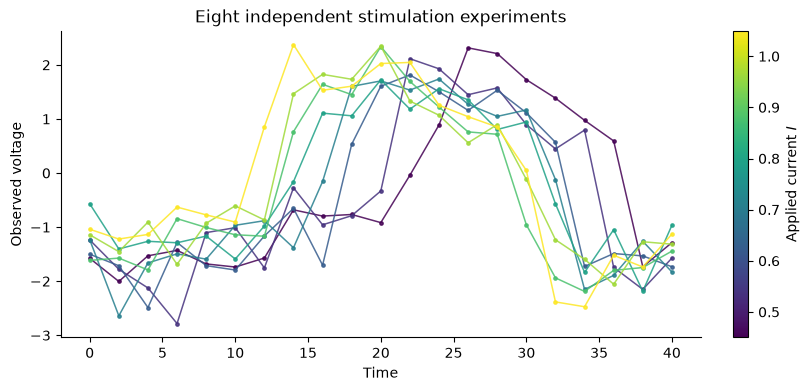

In [ ]:
TRUE_PARAMETERS = np.array([0.72, np.log(11.5)], dtype=np.float32)
TEST_CURRENTS = np.linspace(0.45, 1.05, 8, dtype=np.float32)
parameter_panel = np.repeat(TRUE_PARAMETERS[None, :], TEST_CURRENTS.size, axis=0)
observed_panel = observe(parameter_panel, TEST_CURRENTS, test_rng)

fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
color_scale = plt.Normalize(TEST_CURRENTS.min(), TEST_CURRENTS.max())
colors = plt.cm.viridis(color_scale(TEST_CURRENTS))
for experiment, color in zip(observed_panel, colors):
    ax.plot(OBS_TIME, experiment[:, 0], color=color, linewidth=1.1, alpha=0.85, marker="o", markersize=2.4)
    
fig.colorbar(plt.cm.ScalarMappable(norm=color_scale, cmap="viridis"), ax=ax, label="Applied current $I$")
ax.set(xlabel="Time", ylabel="Observed voltage", title="Eight independent stimulation experiments")
ax.spines[["top", "right"]].set_visible(False)


## Train one local posterior

Each training pair contains one parameter draw and one voltage trace. The time-series network compresses the trace, and the diffusion model learns the local posterior score. Training on a single experiment is the only amortization step; composition does not fit another model.

We simulate 10,000 single-experiment training pairs, hold out 1,000 independent pairs for validation, and allow up to 80 epochs. Early stopping restores the best validation weights, so the plotted posterior is not based on an arbitrary final epoch.


In [ ]:
training_data = simulate_dataset(N_TRAIN, training_rng)
validation_data = simulate_dataset(N_VALIDATION, validation_rng)

In [6]:
workflow = bf.CompositionalWorkflow(
    inference_variables="parameters",
    summary_variables="observables",
    summary_network=bf.networks.RecurrentNetwork(hidden_dim=32),
    inference_network=bf.networks.DiffusionModel(subnet_kwargs={"widths": (128,)*3}),
    standardize="all",
)

In [7]:
history = workflow.fit_offline(
    training_data,
    validation_data=validation_data,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.4319 - val_loss: 0.3708
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3788 - val_loss: 0.3520
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3629 - val_loss: 0.3784
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3628 - val_loss: 0.3687
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3469 - val_loss: 0.3334
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3189 - val_loss: 0.3071
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3255 - val_loss: 0.3385
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3075 - val_loss: 0.2864
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2887 - val_loss: 0.2453
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.2656 - val_loss: 0.2425
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2457 - val_loss: 0.2293
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

INFO:bayesflow:Training completed in 1.62 minutes.


The held-out loss checks whether the local score model continues to improve on unseen single experiments. It is a training diagnostic, not a test of the composed posterior; that comparison comes below.


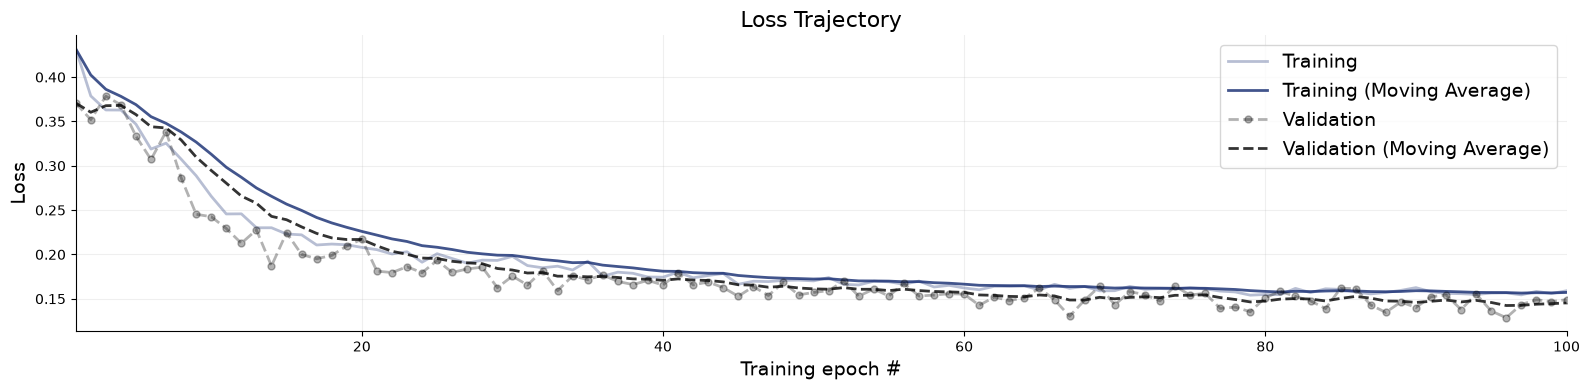

In [8]:
fig = bf.diagnostics.loss(history)

## Add posterior scores, subtract repeated priors

For one experiment we use ordinary posterior sampling. For two or more, `compositional_sample` evaluates the learned score for every trace and combines the results. The function below supplies

$$\nabla_\theta \log p(\theta)
= -\frac{\theta-\mu_0}{\sigma_0^2}$$

for the independent Gaussian prior. BayesFlow handles the coordinate correction introduced by standardization. The condition array has shape `(datasets, experiments, time, channels)`; here there is one dataset and up to eight experiments.


In [9]:
def prior_score(variables):
    parameters = variables["parameters"]
    return {"parameters": -(parameters - PRIOR_MEAN) / PRIOR_SD**2}


posterior_by_experiment_count = {
    1: workflow.sample(
        conditions={"observables": observed_panel[None, 0]},
        num_samples=N_POSTERIOR_SAMPLES,
        seed=301,
    )["parameters"][0]
}

for n_experiments in (2, 4, 8):
    posterior_by_experiment_count[n_experiments] = workflow.compositional_sample(
        conditions={"observables": observed_panel[None, :n_experiments]},
        num_samples=N_POSTERIOR_SAMPLES,
        compute_prior_score=prior_score,
        mini_batch_size=n_experiments,
        seed=300 + n_experiments,
    )["parameters"][0]


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.47 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 5.81 seconds.


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 12.31 seconds.


Every panel below comes from the same trained network. Only the number of score terms changes. The blue samples are diffusion draws; the black contours enclose 50% and 90% of the exact posterior mass from the known observation model. This comparison shows approximation error as well as contraction.


Text(0.5, 0.98, 'Accumulating evidence: diffusion samples and exact posterior contours')

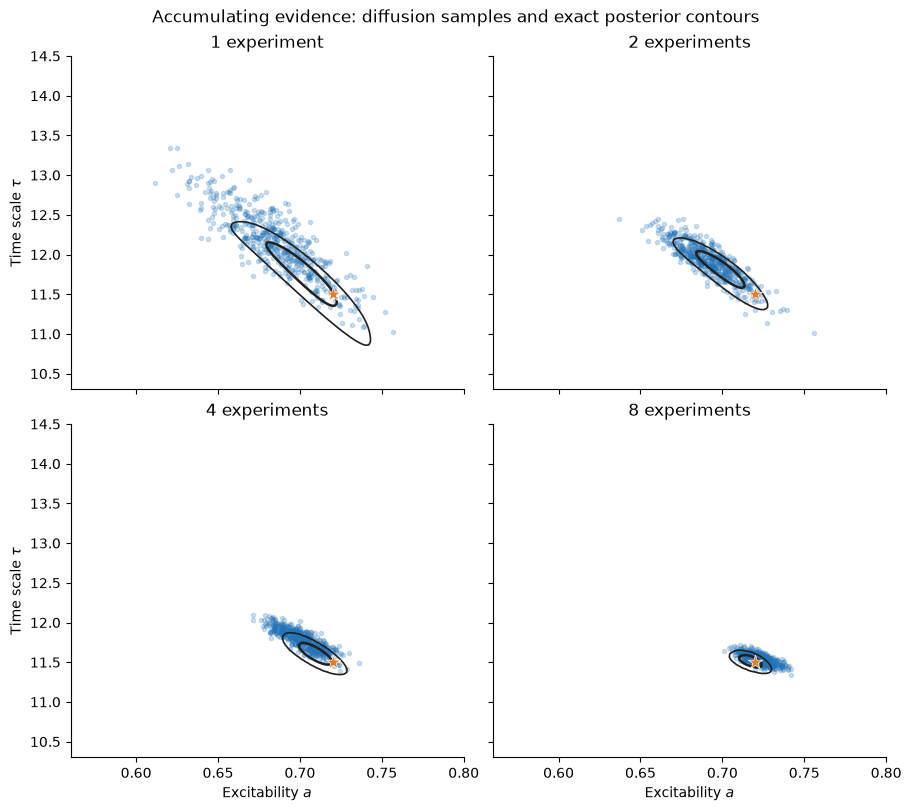

In [10]:
grid_size = 350
a_values = np.linspace(0.46, 0.94, grid_size, dtype=np.float32)
log_tau_values = np.linspace(np.log(7.0), np.log(22.0), grid_size, dtype=np.float32)
a_grid, log_tau_grid = np.meshgrid(a_values, log_tau_values)
grid_parameters = np.column_stack((a_grid.ravel(), log_tau_grid.ravel()))
log_posterior = -0.5 * np.sum(((grid_parameters - PRIOR_MEAN) / PRIOR_SD) ** 2, axis=1)
reference_by_experiment_count = {}

for index, experiment in enumerate(observed_panel, start=1):
    currents = np.full(grid_parameters.shape[0], experiment[0, 1], dtype=np.float32)
    residual = experiment[:, 0] - simulate_voltage(grid_parameters, currents)[:, ::8]
    log_posterior -= np.sum(residual**2, axis=1) / (2.0 * NOISE_SD**2)
    if index in posterior_by_experiment_count:
        reference = np.exp(log_posterior - np.max(log_posterior)).reshape(a_grid.shape)
        reference_by_experiment_count[index] = reference / reference.sum()

fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True, layout="constrained")
for ax, (count, samples) in zip(axes.flat, posterior_by_experiment_count.items()):
    reference = reference_by_experiment_count[count]
    sorted_mass = np.sort(reference.ravel())[::-1]
    cumulative_mass = np.cumsum(sorted_mass)
    outer = sorted_mass[np.searchsorted(cumulative_mass, 0.90)]
    inner = sorted_mass[np.searchsorted(cumulative_mass, 0.50)]
    ax.contour(a_grid, np.exp(log_tau_grid), reference, levels=(outer, inner), colors="#202020", linewidths=(1.2, 1.8))
    ax.scatter(samples[:, 0], np.exp(samples[:, 1]), s=9, alpha=0.22, color="#2273b7", rasterized=True)
    ax.scatter(TRUE_PARAMETERS[0], np.exp(TRUE_PARAMETERS[1]), marker="*", s=115, color="#e08028", edgecolor="white", linewidth=0.5, zorder=5)
    ax.set(title=f"{count} experiment{'s' if count > 1 else ''}", xlim=(0.56, 0.80), ylim=(10.3, 14.5))
    ax.spines[["top", "right"]].set_visible(False)
    
for ax in axes[-1]:
    ax.set_xlabel(r"Excitability $a$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Time scale $\tau$")
fig.suptitle("Accumulating evidence: diffusion samples and exact posterior contours")


## What composition bought us

The training set contained exactly one simulation per parameter draw. At inference time, the same local score model used an arbitrary number of experiments without a second network or a hierarchical latent-variable model. The simulation saving becomes dominant when one forward run is expensive. For instance, training a fixed eight-experiment estimator would require roughly eight times as many forward simulations per parameter draw and a specialized network that can process a variable number of experiments.

The construction also states its limits clearly:

- experiments must be conditionally independent given the shared parameters and known settings;
- adding experiments does not repair a poorly trained local score model, and score errors may accumulate;
- posterior recovery and calibration should be checked over many simulated datasets before scientific use.
